# Data Processing & Modeling


On this step, the data will be processed and used to model some algorithms and evaluate their performance.

## Imports

In [1]:
# Analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from geopandas import sjoin_nearest
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Data
base_path = "../../data/raw"
mining_facilities_df = gpd.read_parquet(f"{base_path}/mining_facilities_df.parquet")
geochemistry_under_analysis_df = gpd.read_parquet(f"{base_path}/geochemistry_under_analysis_df.parquet")
geochemistry_published_df = gpd.read_parquet(f"{base_path}/geochemistry_published_df.parquet")
subsubbasins_df = gpd.read_parquet(f"{base_path}/subsubbasins_df.parquet")

# Environment
import os
from dotenv import load_dotenv
load_dotenv()

# Others
import joblib
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
import contextily as ctx
import matplotlib.pyplot as plt


mapbox = ctx.providers.MapBox(
    id="mapbox/satellite-streets-v12",
    accessToken=os.getenv("MAPBOX_API_KEY")
)

## Data Processing

Mining facilities were updated in July 2026, while the geochemistry records were collected between 2013 and 2017

In [2]:
print(
    f"Facilities shape: {mining_facilities_df.shape}",
    f"\nFacilities GIS updated date: \n{mining_facilities_df['fecha_actualizacion_gis'].value_counts()}",
    f"\nGeochimestry published shape: {geochemistry_published_df.shape}",
    f"\nGeochimestry published measure date: \n{geochemistry_published_df['Fecha_del_muestreo'].value_counts(sort=True).head(20)}"
)

Facilities shape: (37635, 34) 
Facilities GIS updated date: 
fecha_actualizacion_gis
2026-07-20    37635
Name: count, dtype: int64 
Geochimestry published shape: (6097, 82) 
Geochimestry published measure date: 
Fecha_del_muestreo
marzo 2013         258
Agosto 2014        240
Junio 2014         196
Julio 2014         196
Agosto 2011        166
Octubre 2013       157
Enero 2013         151
Junio 2013         146
Enero 2014         135
Septiembre 2013    130
Abril 2011         127
Octubre 2016       123
Septiembre 2016    118
Septiembre 2011    112
Octubre 2011       109
Enero 2017          98
Septiembre 2014     94
Febrero 2014        93
junio 2012          86
junio 2015          86
Name: count, dtype: int64[pyarrow]


### Planning
|Features | Target|
|---|---|
|Measurements across the regions considered| Prospection signal (measurements near a mine and within a subsubbasin)|

The problem could fit with a [Basic Exploration](https://www.codelcoeduca.cl/codelcoeduca/site/edic/base/port/exploracion.html) described in Codelco Educa Webpage, since we are looking with limited information and not focus in a specific region.

A potential bias is that a model can learn from previous mine selection techniques, instead of paying more attention to the measurements. Therefore, it depends on the variety and quality of the data.

### Features
The geochemistry records are divided into published (checked) and under analysis (unchecked). These will be grouped into a single `geochemistry_df` while preserving the differences between them.

Then, a subsubbasin code will be associated with each measurement.

In [3]:
# grouping
geochemistry_under_analysis_df["geochemistry_published"] = False
geochemistry_published_df["geochemistry_published"] = True
geochemistry_df = pd.concat([geochemistry_under_analysis_df, geochemistry_published_df])

# subsubbasin association
geochemistry_df = geochemistry_df.to_crs(32719)
geochemistry_df = gpd.sjoin(
    geochemistry_df,
    subsubbasins_df,
    how="inner",
    predicate="within"
)
geochemistry_df["COD_SSUBC_measure"] = geochemistry_df["COD_SSUBC"]

`geochemistry_df` contains measurements stored as strings, but they need to be converted to numeric values to be used in the model.

The measurements contain special value that we need to consider:
- `sin datos` / `-` / `<NA>` / `s/a` (there is not a measure)
- `IS` (insufficient sample)
- `<x.xxx` / `>x.xxx` (the measure is below or above a specific detection limit)

In [4]:
geochemistry_df_transformed = geochemistry_df.copy()

# selecting measurement columns
measurements = [ 
        'CTOTAL___', 'STOTAL__', 'LOI', 'Suma', 
        'SiO2', 'Al2O3', 'Fe2O3', 'MgO', 'CaO', 'Na2O', 'K2O', 'TiO2', 'P2O5', 'MnO', 'Cr2O3',
        'Sc', 'Ba', 'Be', 'Co', 'Cs', 'Ga', 'Hf', 'Nb', 'Rb', 'Sn', 'Sr', 'Ta', 'Th', 'U', 'V', 'W', 'Zr', 'Y', 
        'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 
        'Mo', 'Cu', 'Pb', 'Zn', 'Ni', 'As_', 'Cd', 'Sb', 'Bi', 'Ag', 'Au', 'Hg', 'Tl', 'Se', 'Te_ppm', 'B_ppm'    
]

# standardize decimal separators
def replace_comma_dot(x):
    if isinstance(x, float):
        return x
    if x is None or x is pd.NA:
        return None
    x = x.replace(",,", ",")
    if "," in x and "." not in x:
        return x.replace(",", ".")
    if "." in x and "," not in x:
        return x
    if "." in x and "," in x:
        x_splited = x.split(",")
        if len(x_splited) > 2:
            x = f"{x_splited[0]},{''.join(x_splited[1:])}"
        return x.replace(".", "").replace(",", ".")
    return x

# remove extra zeros of a number
def less_than_remove_extra_zeros(x):
    if isinstance(x, str) and x[0] == "<":
        num = float(x[1:])
        return f"<{num}"
    return x

def formatting_numeric_values(df):
    df = df.copy()
    for measurement in measurements:
        # formatting
        df[measurement] = df[measurement].apply(replace_comma_dot).apply(less_than_remove_extra_zeros)
    return df
def initialize_categorical_columns(df):
    df = df.copy()
    categorical_columns = ['CTOTAL____isna', 'STOTAL___isna', 'SiO2_isna', 'Al2O3_isna', 'Fe2O3_isna', 'MgO_isna',
    'CaO_isna', 'Na2O_isna', 'K2O_isna', 'TiO2_isna', 'P2O5_isna', 'MnO_isna', 'Cr2O3_insufficient_sample', 'Cr2O3_<0.002',
    'LOI_isna', 'Suma_isna', 'Sc_isna', 'Ba_isna', 'Be_insufficient_sample', 'Be_<1.0', 'Co_isna', 'Cs_isna', 'Ga_isna', 'Hf_isna',
    'Nb_isna', 'Rb_isna', 'Sn_insufficient_sample', 'Sn_<1.0', 'Sr_isna', 'Ta_isna', 'Th_isna', 'U_isna', 'V_isna', 'W_isna',
    'Zr_isna', 'Y_isna', 'La_isna', 'Ce_isna', 'Pr_isna', 'Nd_isna', 'Sm_isna', 'Eu_isna', 'Gd_isna', 'Tb_isna', 'Dy_isna',
    'Ho_isna', 'Er_isna', 'Tm_isna', 'Yb_isna', 'Lu_isna', 'Mo_isna', 'Cu_isna', 'Pb_isna', 'Zn_isna', 'Ni_isna', 'As__isna',
    'Cd_insufficient_sample', 'Cd_<0.1', 'Sb_insufficient_sample', 'Sb_<0.1', 'Sb_>2000.0', 'Bi_insufficient_sample', 'Bi_<0.1',
    'Ag_insufficient_sample', 'Ag_<0.1', 'Au_insufficient_sample', 'Au_<0.5', 'Hg_insufficient_sample', 'Hg_<0.01',
    'Tl_insufficient_sample', 'Tl_<0.1', 'Se_insufficient_sample', 'Se_<0.5', 'Te_ppm_isna', 'Te_ppm_<0.2', 'B_ppm_isna', 
    'B_ppm_<3.0']
    for column in categorical_columns:
        if column not in df.columns:
            df[column] = False
    return df

def add_categorical_columns(df):
    df = df.copy()
    new_measurements_columns = {}
    for measurement in measurements:
        if not pd.api.types.is_float_dtype(df[measurement]):
            # define filters
            isna_filter = ((df[measurement].isna()) | 
            (df[measurement] == "sin datos") | 
            (df[measurement] == "-") | 
            (df[measurement] == "s/a"))
            insufficient_sample_filter = df[measurement] == "IS"
            starts_with_less_than_filter = ((df[measurement].str.startswith("<")) & 
            (~df[measurement].isna()))
            starts_with_more_than_filter = ((df[measurement].str.startswith(">")) & 
            (~df[measurement].isna()))
                
            # Add new categorical columns
            if isna_filter.sum() > 0:
                new_measurements_columns[f"{measurement}_isna"] = isna_filter
            if insufficient_sample_filter.sum() > 0:
                new_measurements_columns[f"{measurement}_insufficient_sample"] = insufficient_sample_filter
            if starts_with_less_than_filter.sum() >0:
                minimum = df[starts_with_less_than_filter].iloc[0][measurement]
                new_measurements_columns[f"{measurement}_{minimum}"] = starts_with_less_than_filter
            if starts_with_more_than_filter.sum() >0:
                maximum = df[starts_with_more_than_filter].iloc[0][measurement]
                new_measurements_columns[f"{measurement}_{maximum}"] = starts_with_more_than_filter
        else:
            isna_filter = df[measurement].isna()
            # Add new categorical columns
            if isna_filter.sum() > 0:
                new_measurements_columns[f"{measurement}_isna"] = isna_filter
    if new_measurements_columns:
        df = pd.concat([df, pd.DataFrame(new_measurements_columns, index=df.index)], axis=1)
    df = initialize_categorical_columns(df)
    return df

def get_median(df, measurement):
    df = df.copy()
    if not pd.api.types.is_float_dtype(df[measurement]):
        # define filters
        isna_filter = ((df[measurement].isna()) | 
        (df[measurement] == "sin datos") | 
        (df[measurement] == "-") | 
        (df[measurement] == "s/a"))
        insufficient_sample_filter = df[measurement] == "IS"
        starts_with_less_than_filter = ((df[measurement].str.startswith("<")) & 
        (~df[measurement].isna()))
        starts_with_more_than_filter = ((df[measurement].str.startswith(">")) & 
        (~df[measurement].isna()))
        # calculate the median
        median = pd.to_numeric(df[(
                (~isna_filter) &
                (~insufficient_sample_filter) & 
                (~starts_with_less_than_filter) &
                (~starts_with_more_than_filter))
                ][measurement]).median()
        return median
    else:
        return df[measurement].median()

def fill_with_median(df, df_for_median=None):
    df = df.copy()
    new_measurements_columns = {}
    for measurement in measurements:
        if not pd.api.types.is_float_dtype(df[measurement]):
            # define filters
            isna_filter = ((df[measurement].isna()) | 
            (df[measurement] == "sin datos") | 
            (df[measurement] == "-") | 
            (df[measurement] == "s/a"))
            insufficient_sample_filter = df[measurement] == "IS"
            starts_with_less_than_filter = ((df[measurement].str.startswith("<")) & 
            (~df[measurement].isna()))
            starts_with_more_than_filter = ((df[measurement].str.startswith(">")) & 
            (~df[measurement].isna()))
            if df_for_median is None:
                median = get_median(df, measurement)
            else:
                median = get_median(df_for_median, measurement)
            # assing the median
            df.loc[
                (isna_filter) |
                (insufficient_sample_filter) |
                (starts_with_less_than_filter) |
                (starts_with_more_than_filter)
                , [measurement]] = str(median)
            # convert to float
            df[measurement] = df[measurement].astype(float)
        else:
            if df_for_median is None:
                median = get_median(df, measurement)
            else:
                median = get_median(df_for_median, measurement)
            df[measurement] = df[measurement].fillna(median)
    return df

geochemistry_df_transformed = formatting_numeric_values(geochemistry_df_transformed)
geochemistry_df_transformed = add_categorical_columns(geochemistry_df_transformed)
geochemistry_df_transformed = fill_with_median(geochemistry_df_transformed)

The resulting `geochemistry_df_transformed` contains several interesting columns, but as a first iteration we are going to focus on the measurements preprocessed previously.

Then, we apply a logarithmic transformation to the numeric measurement values, because some measurements can be very small and difficult for the model to learn from.

In [5]:
# filtering
measurements_df = geochemistry_df_transformed[[
    'CTOTAL___', 'STOTAL__', 'Suma', 'LOI', 'SiO2', 'Al2O3', 'Fe2O3', 'MgO', 'CaO', 'Na2O', 'K2O', 'TiO2', 'P2O5', 'MnO', 'Cr2O3',
    'Sc', 'Ba', 'Be', 'Co', 'Cs', 'Ga', 'Hf', 'Nb', 'Rb', 'Sn', 'Sr', 'Ta', 'Th', 'U', 'V', 'W', 'Zr', 'Y', 'La', 'Ce', 'Pr', 'Nd',
    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Mo', 'Cu', 'Pb', 'Zn', 'Ni', 'As_', 'Cd', 'Sb', 'Bi', 'Ag', 'Au',
    'Hg', 'Tl', 'Se', 'Te_ppm', 'B_ppm', 
    
    'CTOTAL____isna', 'STOTAL___isna', 'SiO2_isna', 'Al2O3_isna', 'Fe2O3_isna', 'MgO_isna',
    'CaO_isna', 'Na2O_isna', 'K2O_isna', 'TiO2_isna', 'P2O5_isna', 'MnO_isna', 

    'Cr2O3_insufficient_sample', 'Cr2O3_<0.002',
    
    'LOI_isna', 'Suma_isna', 'Sc_isna', 'Ba_isna', 
    'Be_insufficient_sample', 'Be_<1.0', 
    'Co_isna', 'Cs_isna', 'Ga_isna', 'Hf_isna',
    'Nb_isna', 'Rb_isna', 
    
    'Sn_insufficient_sample', 'Sn_<1.0', 
    
    'Sr_isna', 'Ta_isna', 'Th_isna', 'U_isna', 'V_isna', 'W_isna',
    'Zr_isna', 'Y_isna', 'La_isna', 'Ce_isna', 'Pr_isna', 'Nd_isna', 'Sm_isna', 'Eu_isna', 'Gd_isna', 'Tb_isna', 'Dy_isna',
    'Ho_isna', 'Er_isna', 'Tm_isna', 'Yb_isna', 'Lu_isna', 'Mo_isna', 'Cu_isna', 'Pb_isna', 'Zn_isna', 'Ni_isna', 'As__isna',
    
    'Cd_insufficient_sample', 'Cd_<0.1', 'Sb_insufficient_sample', 'Sb_<0.1', 'Sb_>2000.0', 'Bi_insufficient_sample', 'Bi_<0.1',
    'Ag_insufficient_sample', 'Ag_<0.1', 'Au_insufficient_sample', 'Au_<0.5', 'Hg_insufficient_sample', 'Hg_<0.01',
    'Tl_insufficient_sample', 'Tl_<0.1', 'Se_insufficient_sample', 'Se_<0.5', 'Te_ppm_isna', 'Te_ppm_<0.2', 'B_ppm_isna', 
    'B_ppm_<3.0', 

    'OBJECTID_left', 'geochemistry_published', 'SHAPE', 'COD_SSUBC_measure'
]]

# logarithmic transformation
def logarithm_transformation(df):
    df = df.copy()
    measurements_without_loi = [ 
            'CTOTAL___', 'STOTAL__', 'Suma', 
            'SiO2', 'Al2O3', 'Fe2O3', 'MgO', 'CaO', 'Na2O', 'K2O', 'TiO2', 'P2O5', 'MnO', 'Cr2O3',
            'Sc', 'Ba', 'Be', 'Co', 'Cs', 'Ga', 'Hf', 'Nb', 'Rb', 'Sn', 'Sr', 'Ta', 'Th', 'U', 'V', 'W', 'Zr', 'Y', 
            'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 
            'Mo', 'Cu', 'Pb', 'Zn', 'Ni', 'As_', 'Cd', 'Sb', 'Bi', 'Ag', 'Au', 'Hg', 'Tl', 'Se', 'Te_ppm', 'B_ppm'    
    ]
    df[measurements_without_loi] = np.log1p(df[measurements_without_loi])
    return df
measurements_df.to_parquet("../../data/interim/measurements_without_log_df.parquet", index=False)
measurements_df = logarithm_transformation(measurements_df)
measurements_df.to_parquet("../../data/interim/measurements_log_df.parquet", index=False)
measurements_df.shape

(7199, 144)

Mining facilities need to be filtered to identify mines, considering the `tipo_instalacion` (mines) and `recurso_principal_instalacion` (copper, gold) columns.

Then, similarly a subsubbasin code will be associated with each mine.

In [6]:
# tipo_instalacion filter
tipo_instalacion_mine_potential_status = [
    "MINA SUBTERRANEA",
    "MINA RAJO ABIERTO"
]

mining_facilities_filtered_df = mining_facilities_df[mining_facilities_df["tipo_instalacion"].isin(tipo_instalacion_mine_potential_status)].copy()
print(
    f"Original Facilities shape: {mining_facilities_df.shape}",
    f"\nRemaining Facilities after `tipo_instalacion_mine_potential_status` filter: {mining_facilities_filtered_df.shape}"
)
# recurso_principal_instalacion filter
recurso_principal_instalacion_resources = [
    "COBRE", 
    "ORO" 
]
print(
    f"Previous Facilities shape: {mining_facilities_filtered_df.shape}",
    f"\nRemaining Facilities after `recurso_principal_instalacion_resources` filter: {mining_facilities_filtered_df[mining_facilities_filtered_df['recurso_principal_instalacion'].isin(recurso_principal_instalacion_resources)].shape}"
)

mines_df = mining_facilities_filtered_df[mining_facilities_filtered_df["recurso_principal_instalacion"].isin(recurso_principal_instalacion_resources)].copy()

# subsubbasin association
mines_df = mines_df.to_crs(32719)
mines_df = gpd.sjoin(
    mines_df,
    subsubbasins_df,
    how="inner",
    predicate="within"
)
mines_df["COD_SSUBC_mine"] = mines_df["COD_SSUBC"]
mines_df.to_parquet("../../data/interim/mines_df.parquet", index=False)

Original Facilities shape: (37635, 34) 
Remaining Facilities after `tipo_instalacion_mine_potential_status` filter: (16920, 34)
Previous Facilities shape: (16920, 34) 
Remaining Facilities after `recurso_principal_instalacion_resources` filter: (15490, 34)


We will verify the mine coordinates on maps using a sample of 20 records.
<div class="alert alert-warning" role="alert">
  ⚠️ Rendering maps
</div>

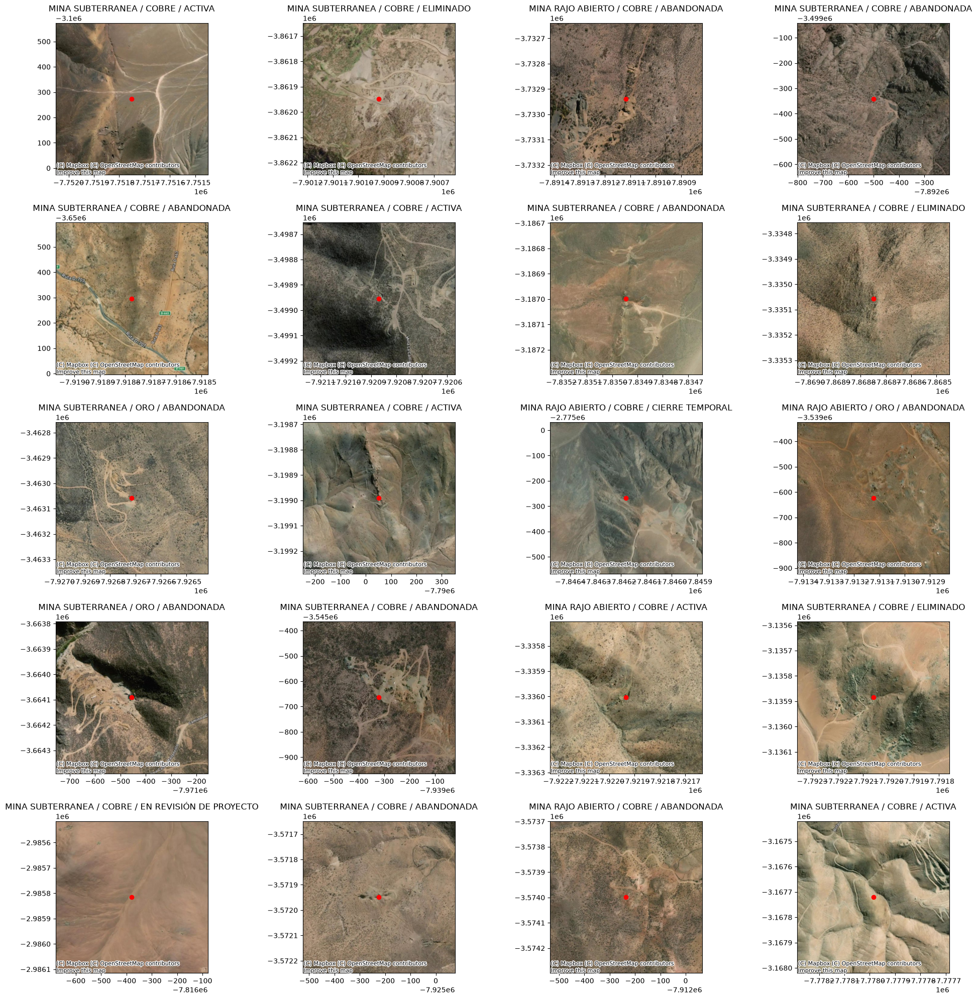

In [7]:
mine_samples = mines_df.sample(n=20, random_state=42)
mine_samples = mine_samples.to_crs("EPSG:3857")
indexes = np.array(mine_samples.index)
fig, axes = plt.subplots(5, 4, figsize=(20, 20))

buffer = 300
for i, ax in enumerate(axes.flatten()):
    index = indexes[i]
    mine = mine_samples[mine_samples.index == index]
    mine.plot(ax=ax, color="red", zorder=5)
    center = mine.geometry.centroid.iloc[0]
    cx, cy = center.x, center.y    
    ax.set_xlim(cx - buffer, cx + buffer)
    ax.set_ylim(cy - buffer, cy + buffer)
    ax.set_title(f"{mine.iloc[0]['tipo_instalacion']} / {mine.iloc[0]['recurso_principal_instalacion']} / {mine.iloc[0]['estado_instalacion']}")
    ctx.add_basemap(ax=ax, source=mapbox, zoom=16)
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(
    "../../images/mine_locations_check.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

### Target

In order to obtain the target, we will calculate the distance in meters between each measurement and its nearest mine, followed by checking whether the measurement and the mine have the same subsubbasin code.

The maximun distance considered for a relationship between a  measurement and a mine will be 3000 meters.

In [8]:
measurements_df = measurements_df.to_crs("EPSG:32719")
mines_df = mines_df.to_crs("EPSG:32719")
mines_df['savedgeom'] = mines_df.geometry

measurements_df = measurements_df.copy()
mines_df = mines_df.copy()

# finding nearest mine
measurements_df_with_distance = sjoin_nearest(
    measurements_df,
    mines_df[["savedgeom", "SHAPE", "COD_SSUBC_mine"]],
    how="left",
    distance_col="distance_m"
)
measurements_df_with_distance = (
    measurements_df_with_distance
    .sort_values(["OBJECTID_left", "distance_m"])
    .drop_duplicates("OBJECTID_left", keep="first")
)

# verify distance
measurements_df_with_distance["within_distance"] = (measurements_df_with_distance["distance_m"] <= 3000)
measurements_df_with_distance["within_distance"].value_counts()

within_distance
False    5819
True     1380
Name: count, dtype: int64

Checking the distance between a measurement and the nearest mine.
<div class="alert alert-warning" role="alert">
  ⚠️ Rendering maps
</div>

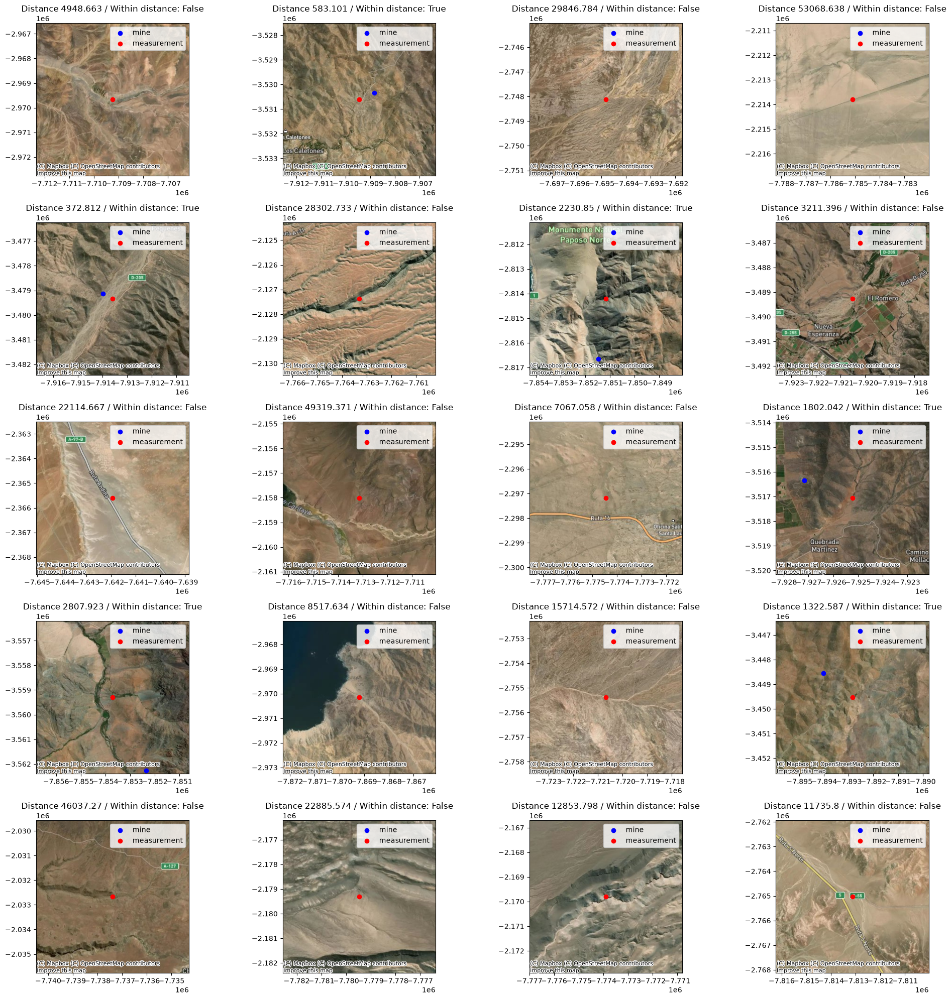

In [9]:
measurements_df_with_distance[["SHAPE", "savedgeom", "distance_m", "within_distance"]].head()
measurements_sample = measurements_df_with_distance.sample(n=20, random_state=42)

indexes = np.array(measurements_sample.index)
fig, axes = plt.subplots(5, 4, figsize=(20, 20))

buffer = 3100
for i, ax in enumerate(axes.flatten()):
    index = indexes[i]
    measurement = measurements_sample[measurements_sample.index == index]
    measurement = measurement.set_geometry("savedgeom")
    measurement = measurement.to_crs("EPSG:3857")
    measurement.plot(ax=ax, color="blue", label= "mine", zorder=5)
    measurement = measurement.set_geometry("SHAPE")
    measurement = measurement.to_crs("EPSG:3857")
    measurement.plot(ax=ax, color="red", label= "measurement", zorder=6)
        
    center = measurement.geometry.centroid.iloc[0]
    cx, cy = center.x, center.y    
    ax.set_xlim(cx - buffer, cx + buffer)
    ax.set_ylim(cy - buffer, cy + buffer)
    ax.set_title(f"Distance {round(float(measurement['distance_m'].iloc[0]),3)} / Within distance: {measurement['within_distance'].iloc[0]}")
    ax.legend(loc='upper right')
    ctx.add_basemap(ax=ax, source=mapbox, zoom=12)
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(
    "../../images/mine_measurement_distance_check.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Once the distance is calculated, a condition will be defined as True if the measurement meets the distance requirement and belongs to the same subsubbasin as a mine.

In [11]:
measurements_df_with_distance = (
    measurements_df_with_distance
    .to_crs("EPSG:32719")
)

# same subsubbasin condition
same_subsubbasin = (
    measurements_df_with_distance["COD_SSUBC_mine"]
    == measurements_df_with_distance["COD_SSUBC_measure"]
)

# creating target using conditions
measurements_df_with_distance["target"] = ((measurements_df_with_distance["within_distance"]) & same_subsubbasin)

Then, we get 1324 cases where there is a significant prospecting signal and 5875 measurements where there is no clear signal.

In [12]:
measurements_df_with_distance["target"].value_counts()

target
False    5875
True     1324
Name: count, dtype: int64[pyarrow]

Temporal columns like `distance_m` should be filtered to avoid the model can learn the distance

In [13]:
measurements_df_with_distance_filtered = measurements_df_with_distance[[
    'CTOTAL___', 'STOTAL__', 'SiO2', 'Al2O3', 'Fe2O3', 'MgO', 'CaO', 'Na2O', 'K2O', 'TiO2', 'P2O5', 'MnO', 'Cr2O3', 'LOI', 'Suma',
    'Sc', 'Ba', 'Be', 'Co', 'Cs', 'Ga', 'Hf', 'Nb', 'Rb', 'Sn', 'Sr', 'Ta', 'Th', 'U', 'V', 'W', 'Zr', 'Y', 'La', 'Ce', 'Pr', 'Nd',
    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Mo', 'Cu', 'Pb', 'Zn', 'Ni', 'As_', 'Cd', 'Sb', 'Bi', 'Ag', 'Au',
    'Hg', 'Tl', 'Se', 'Te_ppm', 'B_ppm', 
    'CTOTAL____isna', 'STOTAL___isna', 'SiO2_isna', 'Al2O3_isna', 'Fe2O3_isna', 'MgO_isna',
    'CaO_isna', 'Na2O_isna', 'K2O_isna', 'TiO2_isna', 'P2O5_isna', 'MnO_isna', 'Cr2O3_insufficient_sample', 'Cr2O3_<0.002',
    'LOI_isna', 'Suma_isna', 'Sc_isna', 'Ba_isna', 'Be_insufficient_sample', 'Be_<1.0', 'Co_isna', 'Cs_isna', 'Ga_isna',
    'Hf_isna', 'Nb_isna', 'Rb_isna', 'Sn_insufficient_sample', 'Sn_<1.0', 'Sr_isna', 'Ta_isna', 'Th_isna', 'U_isna', 'V_isna',
    'W_isna', 'Zr_isna', 'Y_isna', 'La_isna', 'Ce_isna', 'Pr_isna', 'Nd_isna', 'Sm_isna', 'Eu_isna', 'Gd_isna', 'Tb_isna',
    'Dy_isna', 'Ho_isna', 'Er_isna', 'Tm_isna', 'Yb_isna', 'Lu_isna', 'Mo_isna', 'Cu_isna', 'Pb_isna', 'Zn_isna', 'Ni_isna',
    'As__isna', 'Cd_insufficient_sample', 'Cd_<0.1', 'Sb_insufficient_sample', 'Sb_<0.1', 'Sb_>2000.0', 'Bi_insufficient_sample',
    'Bi_<0.1', 'Ag_insufficient_sample', 'Ag_<0.1', 'Au_insufficient_sample', 'Au_<0.5', 'Hg_insufficient_sample', 'Hg_<0.01',
    'Tl_insufficient_sample', 'Tl_<0.1', 'Se_insufficient_sample', 'Se_<0.5', 'Te_ppm_isna', 'Te_ppm_<0.2', 'B_ppm_isna', 'B_ppm_<3.0',
    'OBJECTID_left',
    'geochemistry_published',
    'SHAPE',
    'target']].copy()

### Geospatial Splitting

The data should be split considering the coordinates, so first we need to group items with similar spatial characteristics.

In [14]:
coordinates = measurements_df_with_distance_filtered.get_coordinates()

# Create spatial groups
spatial_groups = pd.DataFrame({
    "grid_x": (coordinates["x"] // 60000).astype(int),
    "grid_y": (coordinates["y"] // 60000).astype(int),
})

spatial_groups["spatial_group"] = (
    spatial_groups["grid_x"].astype(str) + "_" +
    spatial_groups["grid_y"].astype(str)
)

measurements_df_spatial_groups = pd.concat(
    [measurements_df_with_distance_filtered, spatial_groups],
    axis=1
)
measurements_df_spatial_groups.to_parquet("../../data/interim/measurements_df_spatial_groups.parquet", index=False)

Checking spatial groups created before.
<div class="alert alert-warning" role="alert">
  ⚠️ Rendering maps
</div>

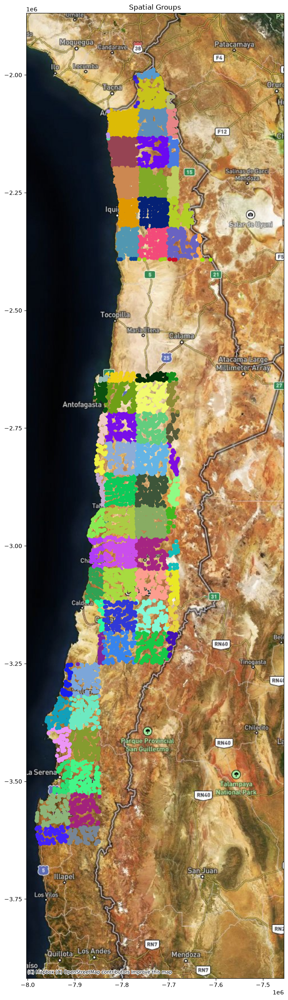

In [15]:
measurements_df_spatial_groups = measurements_df_spatial_groups.to_crs(3857)
groups = list(measurements_df_spatial_groups["spatial_group"].unique())
xlim = (-8003262.609571, -7455361.990823)
ylim = (-3918467.818011, -1868732.467516)

fig, ax = plt.subplots(figsize=(30,30))
for group in groups:
    color = tuple(np.random.choice(range(256), size=3)/255)
    measurements_df_spatial_groups[measurements_df_spatial_groups["spatial_group"] == group].plot(ax=ax, color=color, label=group, aspect="auto")

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ctx.add_basemap(ax=ax, source=mapbox)
ax.set_aspect("equal")

ax.set_title("Spatial Groups")
plt.savefig(
    "../../images/spatial_groups.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Model Training

The data was split using spatial groups, and then a Logistic Regression model was trained.

In [16]:
X = measurements_df_spatial_groups.drop(["OBJECTID_left", "target", "SHAPE", "grid_x", "grid_y"], axis=1)
y = measurements_df_spatial_groups["target"]

# Geospatial splitting
splitter_1 = GroupShuffleSplit(random_state=42, test_size=0.4)
train_inds, _inds = next(splitter_1.split(X, y, groups=X["spatial_group"]))

X_train, X_ = X.iloc[train_inds], X.iloc[_inds] 
y_train, y_ = y.iloc[train_inds], y.iloc[_inds] 

splitter_2 = GroupShuffleSplit(random_state=42, test_size=0.5)
dev_inds, test_inds = next(splitter_2.split(X_, y_, groups=X_["spatial_group"]))

X_dev, X_test = X_.iloc[dev_inds], X_.iloc[test_inds] 
y_dev, y_test = y_.iloc[dev_inds], y_.iloc[test_inds]

X_train = X_train.drop("spatial_group", axis=1)
X_test = X_test.drop("spatial_group", axis=1)
X_dev = X_dev.drop("spatial_group", axis=1)

X_train.to_parquet("../../data/processed/X_train.parquet", index=False)
X_dev.to_parquet("../../data/processed/X_dev.parquet", index=False)
X_test.to_parquet("../../data/processed/X_test.parquet", index=False)

y_train.to_frame("target").to_parquet("../../data/processed/y_train.parquet", index=False)
y_dev.to_frame("target").to_parquet("../../data/processed/y_dev.parquet", index=False)
y_test.to_frame("target").to_parquet("../../data/processed/y_test.parquet", index=False)

print("Train:", X_train.shape, y_train.shape) 
print("Test:", X_test.shape, y_test.shape) 
print("Dev:", X_dev.shape, y_dev.shape)

# Training the model
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)
joblib.dump(
    model,
    "../../models/logistic_regression.joblib"
)

Train: (4354, 141) (4354,)
Test: (1242, 141) (1242,)
Dev: (1603, 141) (1603,)


/home/olver/prospectivity/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['../../models/logistic_regression.joblib']

## Evaluation

Evaluating the model using `classification_report`.

The report evidence a skewed issue, there are many measures that express negative signal of prospection than positive signal of prospection. So the model can learn identify negative values, but not positive values as well.

The model no present a high problem of variance, but bias, considering f1 score 0.53-0.52 it is far from a 0.65 a Bayes error (if we consider a expert committee with a precision of 0.5 and a recall of 0.9 at a regional scale).

In [17]:
y_pred_train = model.predict(X_train)
y_pred_dev = model.predict(X_dev)

print(f"Train: \n {classification_report(y_train, y_pred_train)}")
print(f"\nDev: \n {classification_report(y_dev, y_pred_dev)}")

Train: 
               precision    recall  f1-score   support

         0.0       0.87      0.95      0.91      3478
         1.0       0.69      0.43      0.53       876

    accuracy                           0.85      4354
   macro avg       0.78      0.69      0.72      4354
weighted avg       0.83      0.85      0.83      4354


Dev: 
               precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      1410
         1.0       0.52      0.51      0.52       193

    accuracy                           0.88      1603
   macro avg       0.73      0.72      0.72      1603
weighted avg       0.88      0.88      0.88      1603



Evaluating the model using `confusion_matrix`.

Among all positive cases, the model can identify only 99 out of a total of 193 cases. The model has difficulties identifying the majority of the actual positive cases.

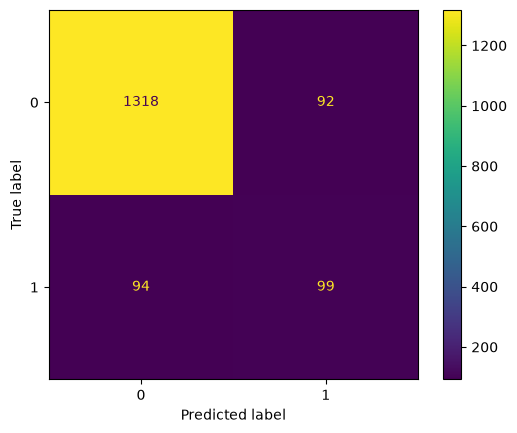

In [18]:
cm = confusion_matrix(y_dev, y_pred_dev)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig(
    "../../images/logistic_regression_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show();

Evaluating the model using `roc_auc_score`.

The ROC-AUC score is 0.86, which means that using different thresholds, the model can perform well by trading off precision and recall. Considering that 0.5 is equivalent to random guessing, the model shows positive signals that it can identify meaninful patterns.

AUC - ROC Score: 0.8617


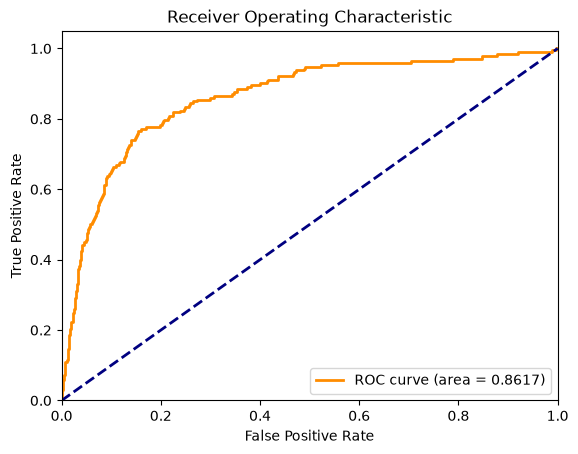

In [19]:
y_prob = model.predict_proba(X_dev)[:, 1]
y_pred = model.predict(X_dev)

roc_auc = roc_auc_score(y_dev, y_prob)
print(f"AUC - ROC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_dev, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig(
    "../../images/logistic_regression_receiver_operating_characteristic.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Experimenting with Another Models

A Random Forest model will be trained.

In [20]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

param_distributions = {
    "n_estimators": [300, 400, 500, 600, 700],
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [20, 30, 40, 50, 60, 70, 80],
    "min_samples_split": [50, 75, 100, 125, 150],
    "max_features": ["sqrt", 0.2, 0.3, 0.4, 0.5],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "criterion": ["gini", "entropy", "log_loss"],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_
joblib.dump(
    best_rf,
    "../../models/random_forest.joblib"
)

print("Best parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 300, 'min_samples_split': 75, 'min_samples_leaf': 20, 'max_features': 0.3, 'max_depth': 4, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}

Best CV ROC-AUC:
0.837607425246547


Evaluating the model using `classification_report`.

The model has a lower f1-score than the previous model. If its performance is also low on the training set, this may indicate higher bias or underfitting.

In [21]:
y_pred_train = best_rf.predict(X_train)
y_pred_dev = best_rf.predict(X_dev)

print(f"Train: \n {classification_report(y_train, y_pred_train)}")
print(f"\nDev: \n {classification_report(y_dev, y_pred_dev)}")

Train: 
               precision    recall  f1-score   support

         0.0       0.95      0.77      0.85      3478
         1.0       0.49      0.85      0.62       876

    accuracy                           0.79      4354
   macro avg       0.72      0.81      0.74      4354
weighted avg       0.86      0.79      0.81      4354


Dev: 
               precision    recall  f1-score   support

         0.0       0.96      0.80      0.87      1410
         1.0       0.35      0.76      0.48       193

    accuracy                           0.80      1603
   macro avg       0.65      0.78      0.68      1603
weighted avg       0.89      0.80      0.83      1603



Evaluating the model using `roc_auc_score`.

The ROC-AUC score is similar 0.86.

AUC - ROC Score: 0.8671


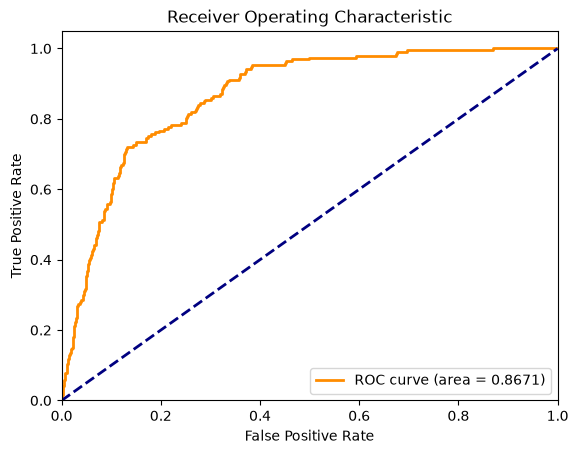

In [22]:
y_prob = best_rf.predict_proba(X_dev)[:, 1]
y_pred = best_rf.predict(X_dev)

roc_auc = roc_auc_score(y_dev, y_prob)
print(f"AUC - ROC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_dev, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig(
    "../../images/random_forest_receiver_operating_characteristic.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

A XGBoost model will be trained.

In [23]:
X_train_xgb = X_train.copy()
X_dev_xgb = X_dev.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .astype(str)
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
)

X_dev_xgb.columns = (
    X_dev_xgb.columns
    .astype(str)
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
joblib.dump(
    xgb,
    "../../models/xgboost.joblib"
)


xgb.fit(X_train_xgb, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Evaluating the model using `classification_report`.

This model produces the highest variance among all the previous models, with f1-scores ranging from 0.73 to 0.51, a difference of about 0.22. This suggests that simpler models may perform better and provide more consistent results across spatial splits.

In [24]:
y_pred_train = xgb.predict(X_train_xgb)
y_pred_dev = xgb.predict(X_dev_xgb)

print(f"Train: \n {classification_report(y_train, y_pred_train)}")
print(f"\nDev: \n {classification_report(y_dev, y_pred_dev)}")

Train: 
               precision    recall  f1-score   support

         0.0       0.92      0.97      0.94      3478
         1.0       0.84      0.64      0.73       876

    accuracy                           0.90      4354
   macro avg       0.88      0.81      0.83      4354
weighted avg       0.90      0.90      0.90      4354


Dev: 
               precision    recall  f1-score   support

         0.0       0.93      0.94      0.94      1410
         1.0       0.53      0.48      0.51       193

    accuracy                           0.89      1603
   macro avg       0.73      0.71      0.72      1603
weighted avg       0.88      0.89      0.88      1603



Evaluating the model using `roc_auc_score`.

The ROC-AUC score is 0.87, which is highest among all the previous models, with an improvement of 0.01.

AUC - ROC Score: 0.8786


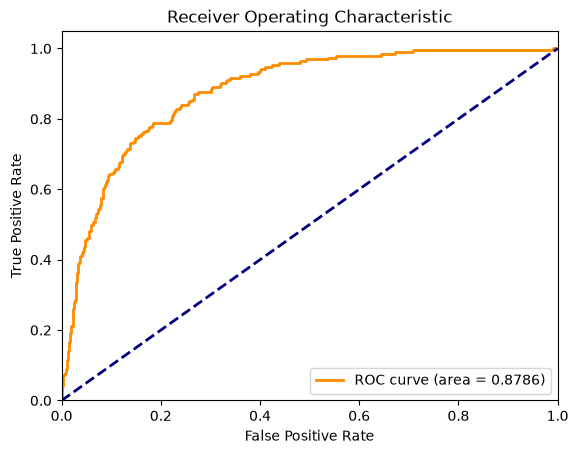

In [25]:
y_prob = xgb.predict_proba(X_dev_xgb)[:, 1]
y_pred = xgb.predict(X_dev_xgb)

roc_auc = roc_auc_score(y_dev, y_prob)
print(f"AUC - ROC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_dev, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig(
    "../../images/xgboost_receiver_operating_characteristic.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Model Selection

As model complexity increases, ROC-AUC improves slightly, but the variability in f1-score also increases.

Therefore, the final decision is to select the first Logistic Regression model, prioritizing lower variability over achieving the highest ROC-AUC score.

## Final Evaluation

So, now the test set will be used to verify the model performance.

Evaluating the model using `classification_report`.

The model does not show a significant signal of variance. The f1-score is equal 0.53.

In [26]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Train: \n {classification_report(y_train, y_pred_train)}")
print(f"\nTest: \n {classification_report(y_test, y_pred_test)}")

Train: 
               precision    recall  f1-score   support

         0.0       0.87      0.95      0.91      3478
         1.0       0.69      0.43      0.53       876

    accuracy                           0.85      4354
   macro avg       0.78      0.69      0.72      4354
weighted avg       0.83      0.85      0.83      4354


Test: 
               precision    recall  f1-score   support

         0.0       0.87      0.95      0.90       987
         1.0       0.68      0.43      0.53       255

    accuracy                           0.84      1242
   macro avg       0.77      0.69      0.72      1242
weighted avg       0.83      0.84      0.83      1242



Evaluating the model using `roc_auc_score`.

The ROC-AUC score is 0.85, which remains within a similar range compared to the previous models.

AUC - ROC Score: 0.8507


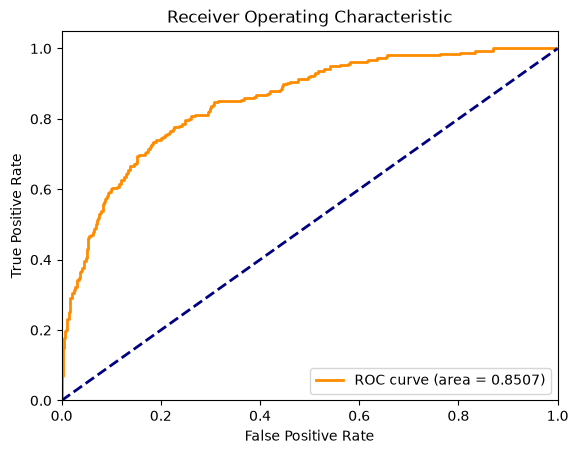

In [27]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_prob)
print(f"AUC - ROC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig(
    "../../images/logistic_regression_receiver_operating_characteristic_using_test_set.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

Evaluating the model using `average_precision_score`.

Another interesting metric is PR-AUC, which measures the relationship between precision and recall across different thresholds.

The baseline in this case is approximately 0.2, while the model achieves 0.64. This indicates that the model has a useful capacity to identify positive cases while maintaining precision across different thresholds.

In [28]:
average_precision_score(y_test, y_prob)

0.6442144795245098

## Predictions

Every measurement will be used to predict a probability. The threshold can be adjusted depending on whether higher precision or higher recall is desired.

In [29]:
X_model = measurements_df_spatial_groups.copy()
y_prob = model.predict_proba(measurements_df_spatial_groups.drop(columns=["OBJECTID_left", "spatial_group", "SHAPE", "grid_x", "grid_y", "target"]))[:, 1]
X_model["probability"] = y_prob
X_model = gpd.GeoDataFrame(
    X_model[["OBJECTID_left", "probability"]].merge(
        geochemistry_df,
        on="OBJECTID_left",
        how="left"
    ),
    geometry="SHAPE",
    crs=geochemistry_df.crs
)
X_model.to_parquet("../../data/processed/prospectivity_map.parquet", index=False)

A prospectivity map will be plotted, highlighting areas with higher prospectivity signals in green and lower signals in red.

One important limitation is that there are more geochemical measurements between La Serena and Vallenar. As a result, this are contains more predicted points and may appear more prominent on the map.

The classification threshold can also be adjusted to obtain a different balance between precision and recall.

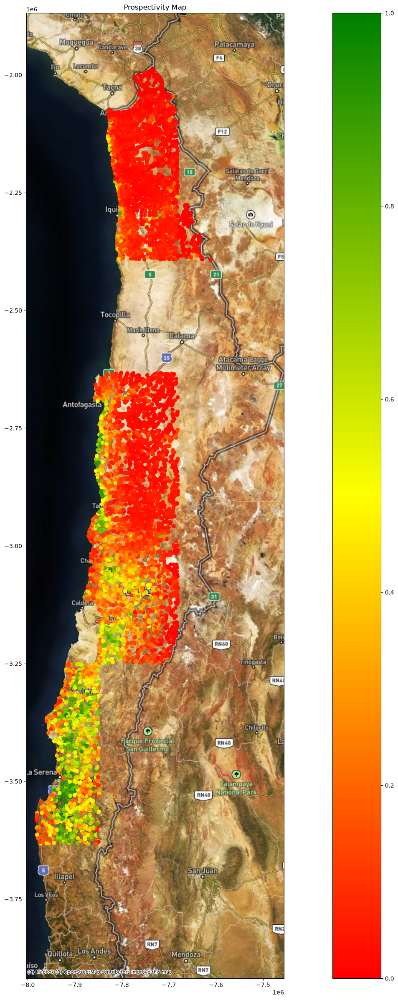

In [30]:
X_model = X_model.to_crs(3857)
xlim = (-8003262.609571, -7455361.990823)
ylim = (-3918467.818011, -1868732.467516)

cmap = LinearSegmentedColormap.from_list(
    "red_yellow_green",
    ["red", "yellow", "green"]
)

fig, ax = plt.subplots(figsize=(30,30))

X_model.plot(
    ax=ax,
    column="probability",
    cmap=cmap,
    vmin=0,
    vmax=1,
    legend=True,
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ctx.add_basemap(ax=ax, source=mapbox)
ax.set_aspect("equal")

ax.set_title("Prospectivity Map")
plt.savefig(
    "../../images/prospectivity_map.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()